# 04 · Sentiment Analysis

**Purpose:** Attach a sentiment signal to every (article, ticker) pair.

- **Primary source:** LLM scores already stored in `sentiment_scores` (PostgreSQL).
- **Fallback:** Simple French lexicon for articles the LLM never processed.

**Input:** `articles_mapped.parquet`, `sentiments.parquet`  
**Output:** `articles_enriched.parquet`  
New columns: `sentiment`, `score`, `confidence`, `sentiment_source`

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

NB_DIR = Path().resolve()
sys.path.insert(0, str(NB_DIR))
from utils import load, save

In [2]:
articles_mapped = load("articles_mapped")
sentiments      = load("sentiments")

print(f"Mapped (article, ticker) pairs: {len(articles_mapped):,}")
print(f"LLM sentiment scores:           {len(sentiments):,}")

Mapped (article, ticker) pairs: 3,557
LLM sentiment scores:           709


## 1 · Merge LLM sentiments

In [3]:
enriched = articles_mapped.merge(
    sentiments[["article_url", "sentiment", "score", "confidence"]],
    on="article_url",
    how="left",
)

llm_coverage = enriched["sentiment"].notna().mean()
print(f"LLM coverage: {llm_coverage:.1%} of (article, ticker) pairs have a score")

enriched["sentiment_source"] = enriched["sentiment"].notna().map(
    {True: "llm", False: "lexicon"}
)

LLM coverage: 67.6% of (article, ticker) pairs have a score


## 2 · French lexicon fallback

In [4]:
POSITIVE_STEMS = [
    "croissance", "hausse", "progression", "bénéfice", "profit",
    "succès", "record", "expansion", "rebond", "gain", "dynamique",
    "excellent", "performant", "amélioration", "solide", "fort",
    "optimiste", "positif", "accroissement", "développement",
]

NEGATIVE_STEMS = [
    "baisse", "chute", "perte", "recul", "déficit", "déclin",
    "difficile", "crise", "risque", "incertitude", "ralentissement",
    "préoccupation", "tension", "négatif", "détérioration",
    "pessimiste", "fragilité", "dégradation",
]


def lexicon_sentiment(text: str) -> dict:
    words = text.lower().split()
    pos = sum(1 for w in words if any(s in w for s in POSITIVE_STEMS))
    neg = sum(1 for w in words if any(s in w for s in NEGATIVE_STEMS))
    total = pos + neg
    if total == 0:
        return {"sentiment": "neutral", "score": 0.0, "confidence": 0.0}
    score = (pos - neg) / total
    label = "positive" if score > 0.1 else "negative" if score < -0.1 else "neutral"
    conf  = round(min(total / max(len(words), 1) * 5, 1.0), 3)  # proxy for confidence
    return {"sentiment": label, "score": round(score, 3), "confidence": conf}

In [5]:
no_score = enriched["sentiment"].isna()
print(f"Rows needing lexicon fallback: {no_score.sum():,}")

if no_score.any():
    lex_results = enriched.loc[no_score, "text"].apply(lexicon_sentiment).apply(pd.Series)
    enriched.loc[no_score, "sentiment"]  = lex_results["sentiment"].values
    enriched.loc[no_score, "score"]      = lex_results["score"].values
    enriched.loc[no_score, "confidence"] = lex_results["confidence"].values

print("\nSentiment distribution:")
print(enriched["sentiment"].value_counts().to_string())

Rows needing lexicon fallback: 1,152

Sentiment distribution:
sentiment
neutral     2201
positive    1113
negative     243


## 3 · Quality check

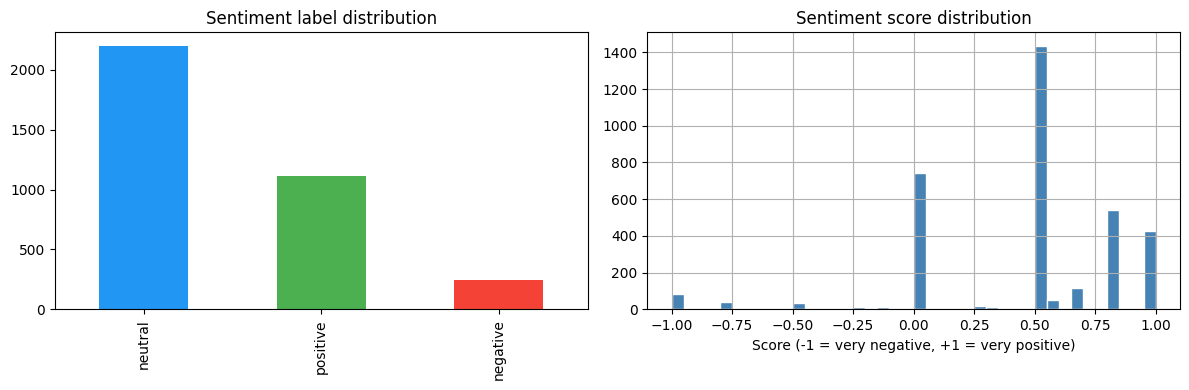


Score stats by label:
            count   mean    std  min  25%  50%  75%  max
sentiment                                               
negative    243.0 -0.324  0.748 -1.0 -1.0 -0.8  0.7  0.8
neutral    2201.0  0.323  0.242 -0.5  0.0  0.5  0.5  0.9
positive   1113.0  0.848  0.144  0.0  0.8  0.8  1.0  1.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

enriched["sentiment"].value_counts().plot.bar(ax=axes[0], color=["#2196F3", "#4CAF50", "#F44336"])
axes[0].set_title("Sentiment label distribution")
axes[0].set_xlabel("")

enriched["score"].hist(bins=40, ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("Sentiment score distribution")
axes[1].set_xlabel("Score (-1 = very negative, +1 = very positive)")

plt.tight_layout()
plt.show()

print("\nScore stats by label:")
print(enriched.groupby("sentiment")["score"].describe().round(3).to_string())

## 4 · Sentiment by event type and source

In [ ]:
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

# ── Sentiment score by LLM event_type (box plots) ─────────────────────────────
# Pull event_type from the full sentiments parquet (has LLM labels)
sentiments_full = load("sentiments")
enriched_et = enriched.merge(
    sentiments_full[["article_url", "event_type"]].dropna(subset=["event_type"]),
    on="article_url",
    how="left",
)
enriched_et["event_type"] = enriched_et["event_type"].fillna("other")

event_order = (
    enriched_et.groupby("event_type")["score"].median()
    .sort_values()
    .index.tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Sentiment by Event Type & Source", fontsize=14, fontweight="bold")

# Box plot: score by event_type
groups = [enriched_et.loc[enriched_et["event_type"] == et, "score"].dropna() for et in event_order]
bp = axes[0].boxplot(groups, labels=event_order, patch_artist=True, vert=False)
for patch in bp["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.6)
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Sentiment score by LLM event_type")
axes[0].set_xlabel("Sentiment score")

# Box plot: score by sentiment_source (LLM vs lexicon)
src_order = ["llm", "lexicon"]
src_groups = [enriched_et.loc[enriched_et["sentiment_source"] == s, "score"].dropna() for s in src_order]
bp2 = axes[1].boxplot(src_groups, labels=src_order, patch_artist=True)
colors2 = ["#4CAF50", "#FF9800"]
for patch, c in zip(bp2["boxes"], colors2):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Score distribution: LLM scorer vs lexicon fallback")
axes[1].set_ylabel("Sentiment score")

plt.tight_layout()
plt.show()

In [ ]:
# ── Sentiment trend over time + feed-level breakdown ──────────────────────────
articles_full = load("articles")
enriched_time = enriched.merge(
    articles_full[["url", "published_at", "feed_name"]],
    left_on="article_url", right_on="url", how="left"
)
enriched_time["published_at"] = pd.to_datetime(enriched_time["published_at"], utc=True)
enriched_time["month"] = enriched_time["published_at"].dt.to_period("M")

monthly_sent = (
    enriched_time[enriched_time["sentiment_source"] == "llm"]
    .groupby("month")["score"]
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Sentiment Trends & Feed Breakdown", fontsize=14, fontweight="bold")

monthly_sent.plot(ax=axes[0], color="steelblue", marker="o", markersize=3)
axes[0].axhline(0, color="black", linewidth=0.7, linestyle="--")
axes[0].set_title("Monthly avg LLM sentiment score over time")
axes[0].set_xlabel("")
axes[0].set_ylabel("Avg score")

# Feed-level sentiment label breakdown (stacked bar, top 8 feeds)
top_feeds = enriched_time["feed_name"].value_counts().head(8).index
feed_sent = (
    enriched_time[enriched_time["feed_name"].isin(top_feeds)]
    .groupby(["feed_name", "sentiment"])
    .size()
    .unstack(fill_value=0)
)
feed_sent_pct = feed_sent.div(feed_sent.sum(axis=1), axis=0) * 100
feed_sent_pct[["positive", "neutral", "negative"]].plot.barh(
    ax=axes[1],
    stacked=True,
    color={"positive": "#4CAF50", "neutral": "#2196F3", "negative": "#F44336"},
)
axes[1].set_title("Sentiment mix by feed (top 8, % of articles)")
axes[1].set_xlabel("% of articles")
axes[1].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

In [7]:
save(enriched, "articles_enriched")

  saved 3,557 rows  →  articles_enriched.parquet


WindowsPath('C:/_PROJECTS/pfa_bvc/Notebooks/signal_pipeline/data/articles_enriched.parquet')